In [1]:
#重启数据库
import pandas as pd
from sqlalchemy import create_engine
# 1. 重建连接
engine = create_engine('mysql+mysqlconnector://root:@127.0.0.1:3306/olist_db')
# 2. 直接读取你今天存好的表
df_raw = pd.read_sql("SELECT * FROM orders_cleaned", engine)
print("finished")

finished


提炼R,F,M指标，划分客户画像

In [2]:
# 1. 确保时间格式正确（SQL读取回来有时会变成字符串）
df_raw['order_purchase_timestamp'] = pd.to_datetime(df_raw['order_purchase_timestamp'])

# 2. 设定“今天”是多少号
# 逻辑：取数据集中最后一次交易的时间，再往后推1天，作为计算基准
snapshot_date = df_raw['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# 3. 核心计算：按客户分组
# R: 算出距离今天过了几天
# F: 算出在这个平台下单了几次
# M: 算出总共花了多少钱（价格+运费）
rfm = df_raw.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, #今天日期-最近一次消费的日期，转为天数
    'order_id': 'nunique',
    'price': lambda x: (x + df_raw.loc[x.index, 'freight_value']).sum()
}).reset_index()

# 重命名
rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

print(f"RFM 基础指标计算完成，共计 {len(rfm)} 位客户。")
display(rfm.head())

RFM 基础指标计算完成，共计 96478 位客户。


,customer_id,Recency,Frequency,Monetary
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74
1,000161a058600d5901f007fab4c27140,410,1,67.41
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35
4,000379cdec625522490c315e70c7a9fb,150,1,107.01


In [5]:
#计算每个customer_id 对应的商品价格+运费的总额，运行太慢了，可以先算每行的price+freight_value求金额，再用sum求和
""" 
df_raw['total_price']=df_raw['price']+df_raw['freight_value']
rfm = df_raw.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, #今天日期-最近一次消费的日期，转为天数
    'order_id': 'nunique',
    'total_price': 'sum'
}).reset_index()
"""

" \ndf_raw['total_price']=df_raw['price']+df_raw['freight_value']\nrfm = df_raw.groupby('customer_id').agg({\n    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, #今天日期-最近一次消费的日期，转为天数\n    'order_id': 'nunique',\n    'total_price': 'sum'\n}).reset_index()\n"

现在的 Recency 是天数，Monetary 是钱数。不同维度的数字没法直接加减，我们要用 “五分位法” (Quantiles) 把所有客户强行分成 5 个等级。
R 评分：天数越小，分数越高（说明最近刚买过）。
F 和 M 评分：数字越大，分数越高（说明买得多、花得多）。

In [6]:
# 使用 pd.qcut 自动将数据切成 5 份
# R_score: 标签是 [5, 4, 3, 2, 1]，因为天数小的排在前面（高分）
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# F_score: 很多人只买过一次，可能会导致切分报错，所以这里用 rank 辅助
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# M_score: 消费金额
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# 把这三个分数拼在一起，形成一个三位数，如 "555", "111"
rfm['RFM_Combined'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

display(rfm.head())

,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Combined
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74,2,1,3,213
1,000161a058600d5901f007fab4c27140,410,1,67.41,1,1,2,112
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42,1,1,4,114
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35,2,1,4,214
4,000379cdec625522490c315e70c7a9fb,150,1,107.01,4,1,3,413


In [11]:
engine.dispose()
# 重新建立连接
from sqlalchemy import create_engine
engine = create_engine('mysql+mysqlconnector://root:@127.0.0.1:3306/olist_db')

# 将最终结果存入名为 'rfm_segmentation_result' 的表
try:
    rfm.to_sql('rfm_segmentation_result', 
           con=engine, 
           if_exists='replace', 
           index=False, 
           chunksize=5000)
    print("saved")
except Exception as e:
    print(f"error: {e}")

saved


In [14]:
# 定义简单的分层逻辑
def segment_customer(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r >= 4 and f >= 4 and m >= 4: return '重要价值客户'
    if r >= 4 and f <= 2: return '重要新客户'
    if r <= 2 and m >= 4: return '重要唤回客户'
    if r <= 2 and m <= 2: return '流失客户'
    return '一般维持客户'

rfm['Customer_Tag'] = rfm.apply(segment_customer, axis=1)
print("标签已生成")

标签已生成


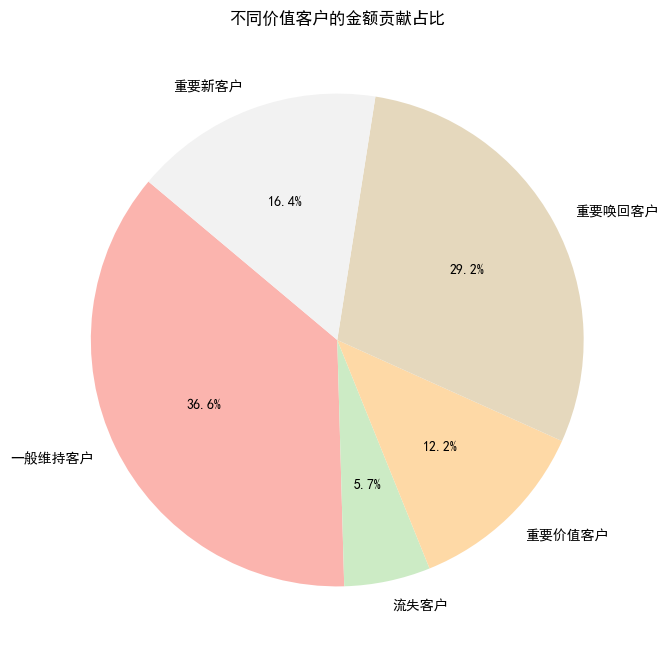

In [15]:
import matplotlib.pyplot as plt

# 统计各组的金额总和
money_dist = rfm.groupby('Customer_Tag')['Monetary'].sum()

plt.figure(figsize=(8, 8))
plt.rcParams['font.sans-serif'] = ['SimHei'] # 支持中文
money_dist.plot.pie(autopct='%1.1f%%', startangle=140, cmap='Pastel1')
plt.title('不同价值客户的金额贡献占比')
plt.ylabel('') # 隐藏纵轴标签
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_24748\2109153230.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Customer_Tag', palette='viridis',


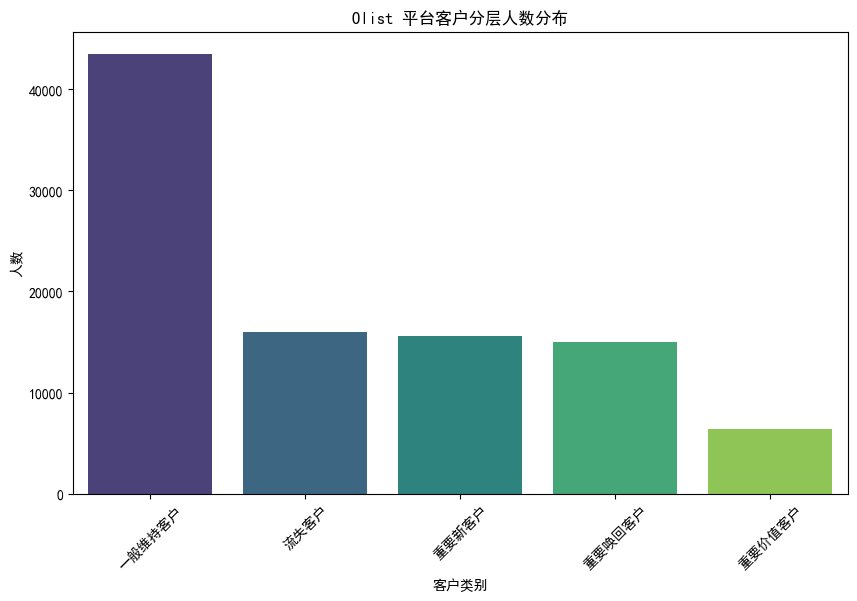

In [16]:
import seaborn as sns

plt.figure(figsize=(10, 6))
# 统计人数并排序
sns.countplot(data=rfm, x='Customer_Tag', palette='viridis', 
              order=rfm['Customer_Tag'].value_counts().index)

plt.title('Olist 平台客户分层人数分布')
plt.xlabel('客户类别')
plt.ylabel('人数')
plt.xticks(rotation=45) # 标签旋转防止重叠
plt.show()

In [18]:
import pandas as pd

# 从 MySQL 读取刚才存进去的表
df_check = pd.read_sql('SELECT * FROM rfm_segmentation_result LIMIT 5', con=engine)

print("数据库读取测试：")
display(df_check)

数据库读取测试：


,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Combined
0,00012a2ce6f8dcda20d059ce98491703,288,1,114.74,2,1,3,213
1,000161a058600d5901f007fab4c27140,410,1,67.41,1,1,2,112
2,0001fd6190edaaf884bcaf3d49edf079,548,1,195.42,1,1,4,114
3,0002414f95344307404f0ace7a26f1d5,379,1,179.35,2,1,4,214
4,000379cdec625522490c315e70c7a9fb,150,1,107.01,4,1,3,413


In [20]:
!pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]



In [21]:
# 提取特定类型的客户
best_customers = rfm[rfm['Customer_Tag'] == '重要价值客户']

# 导出为 Excel 文件
best_customers.to_excel('best_customers_list.xlsx', index=False)
print("冠军客户名单已导出为 best_customers_list.xlsx")

冠军客户名单已导出为 best_customers_list.xlsx
